# Fourier Optics

Consider scalar function $U(t, x, y, z)$ that satisfies the wave equation:

$$
(\nabla^2 - \frac{1}{c^2} \frac{\partial^2}{\partial t^2}) U(t, x, y, z) = 0
$$

where $|U|^2$ is the intensity of the wave. We can express $U$ as a superposition of monochromatic waves:

$$
U(t, x, y, z) =  u(x, y, z, \omega) e^{-i \omega t}
$$

Substituting this into the wave equation gives us the Helmholtz equation:

$$
\nabla^2 u + k^2 u = 0
$$

where $k = \frac{\omega}{c}$ is the wavenumber. The Helmholtz equation describes how the spatial part of the wave behaves in space. 

For separable solutions, we can write $u(x, y, z) = X(x) Y(y) Z(z)$. Thus, we can express the Helmholtz equation as:

$$
\frac{1}{X} \frac{d^2 X}{dx^2} + \frac{1}{Y} \frac{d^2 Y}{dy^2} + \frac{1}{Z} \frac{d^2 Z}{dz^2} + k^2 = 0
$$

From this equation, we can derive the following ordinary differential equations for each spatial component:

$$
\frac{d^2 X}{dx^2} + k_x^2 X = 0
$$

$$
\frac{d^2 Y}{dy^2} + k_y^2 Y = 0
$$

$$
\frac{d^2 Z}{dz^2} + k_z^2 Z = 0
$$

where $k_x^2 + k_y^2 + k_z^2 = k^2$. The solutions to these equations are plane waves of the form:

$$
u(x, y, z) = A e^{i(k_x x + k_y y + k_z z)} = A e^{i(k_x x + k_y y)} e^{\pm i \sqrt{k^2 - k_x^2 - k_y^2} z}
$$

General solution is a superposition of all possible plane waves:

$$
u(x, y, z) = \iint_{-\infty}^\infty A(k_x, k_y) e^{i(k_x x + k_y y)} e^{\pm i \sqrt{k^2 - k_x^2 - k_y^2} z} dk_x dk_y
$$

For particular plane $z = 0$, we have:

$$
u(x, y, 0) = \iint_{-\infty}^\infty A(k_x, k_y) e^{i(k_x x + k_y y)} dk_x dk_y
$$      

This mean that $A(k_x, k_y)$ is the Fourier transform of $u(x, y, 0)$:
$$
A(k_x, k_y) = \mathcal{F}\{u(x, y, 0)\} 
$$

So the field at any plane $z$ can be expressed as:
$$
u(x, y, z) = \iint_{-\infty}^\infty \mathcal{F}\{u(x, y, 0)\} e^{i(k_x x + k_y y)} e^{\pm i \sqrt{k^2 - k_x^2 - k_y^2} z} dk_x dk_y\\
u(x, y, z) = \mathcal{F}^{-1}\{\mathcal{F}\{u(x, y, 0)\} e^{\pm i \sqrt{k^2 - k_x^2 - k_y^2} z}\}
$$

## Single slit diffraction

In [1]:
import pint
unit = pint.UnitRegistry()

In [3]:
D = 0.1 * unit.mm
wavelength = 500 * unit.nm

In [5]:
import numpy as np
x = np.linspace(-2, 2, 1600) * unit.mm
xv, yv = np.meshgrid(x, x)

define initial wavefront as a rectangular function passing through a slit of width $D$:
$$
u(x, y, 0) = rect\left(\frac{x}{D}\right)
$$

where $D$ is the slit width.

In [6]:
U0 = (np.abs(xv) < D/2 ) * (np.abs(yv) < 0.5 * unit.mm)
U0 = U0.astype(float)

/opt/homebrew/lib/python3.13/site-packages/matplotlib/cbook.py:684: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


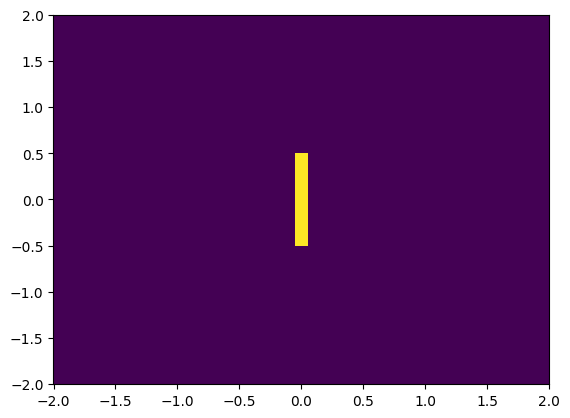

In [9]:
import matplotlib.pyplot as plt
plt.pcolormesh(xv, yv, U0)

Text(0, 0.5, 'ky [1/mm]')

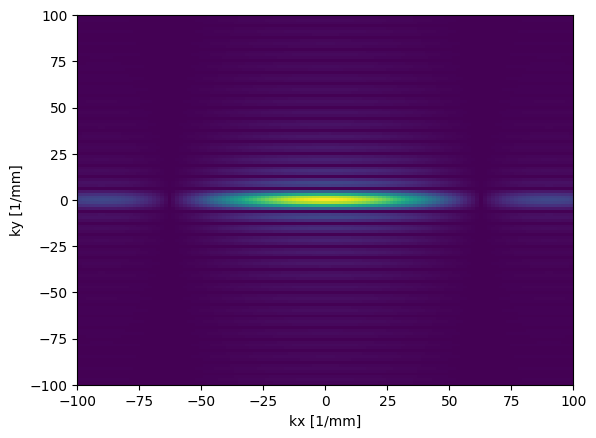

In [11]:
from scipy.fft import fft2, fftfreq, fftshift
A = fft2(U0)
kx = fftfreq(len(x), np.diff(x)[0]) * 2 * np.pi
kxv, kyv = np.meshgrid(kx, kx)

plt.pcolormesh(fftshift(kxv.magnitude), fftshift(kyv.magnitude), np.abs(fftshift(A)))
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.xlabel('kx [1/mm]')
plt.ylabel('ky [1/mm]')

In [14]:
from scipy.fft import ifft2
def get_U(z, k, A, kxv, kyv):
    k = 2 * np.pi / wavelength
    return ifft2(A * np.exp(1j * k * z * np.sqrt(1 - (kxv / k)**2 - (kyv / k)**2)))

/opt/homebrew/lib/python3.13/site-packages/scipy/fft/_basic_backend.py:56: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.asarray(x)
/opt/homebrew/lib/python3.13/site-packages/matplotlib/cbook.py:684: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


Text(0, 0.5, 'y [mm]')

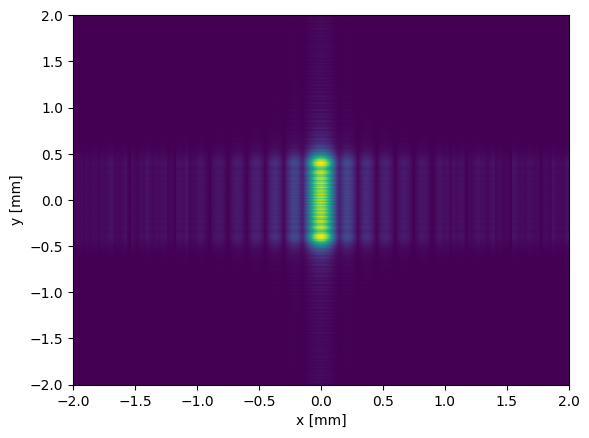

In [15]:
k = 2 * np.pi / wavelength
d = 3 * unit.cm

U = get_U(d, k, A, kxv, kyv)
plt.pcolormesh(xv, yv, np.abs(U))
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')

Now we confirm this result with diffraction theory. 

For single slit diffraction, minima of intensity occur at angles $\theta$ where:
$$D \sin \theta = m \lambda, \quad m = \pm 1, \pm 2, \ldots$$

and 

$$\sin \theta = \frac{x}{\sqrt{x^2 + z^2}}$$

Thus, the minima occur at positions $x$ on the observation plane given by:
$$x = \pm m \frac{\lambda z}{D} = \pm \frac{m \lambda D}{\sqrt{D^2 - m^2 \lambda^2}}$$

In [16]:
m = np.arange(1,5,1)
x_min = np.sqrt(m**2 * wavelength**2 * d**2 / (D**2 + m**2 * wavelength**2)).to(unit.mm)

Text(0, 0.5, 'Intensity [a.u.]')

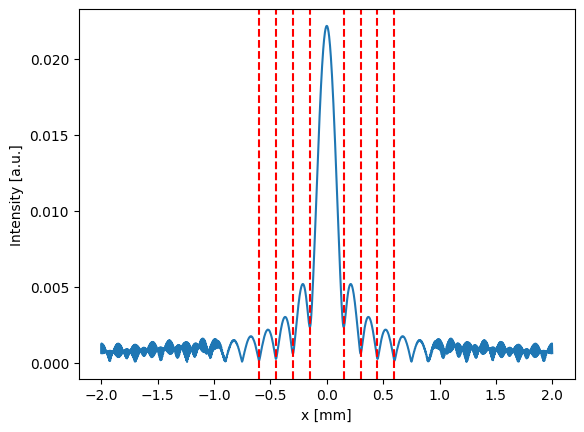

In [21]:
plt.plot(x, np.abs(U)[200])
[plt.axvline(x.magnitude, color='r', linestyle='--') for x in x_min]
[plt.axvline(-x.magnitude, color='r', linestyle='--') for x in x_min]
plt.xlabel('x [mm]')
plt.ylabel('Intensity [a.u.]')

## Double slit diffraction

Define distance between the two slits as $d$ and slit width as $D$. The initial wavefront can be expressed as:

$$u(x, y, 0) = rect\left(\frac{x - d/2}{D}\right) + rect\left(\frac{x + d/2}{D}\right)$$

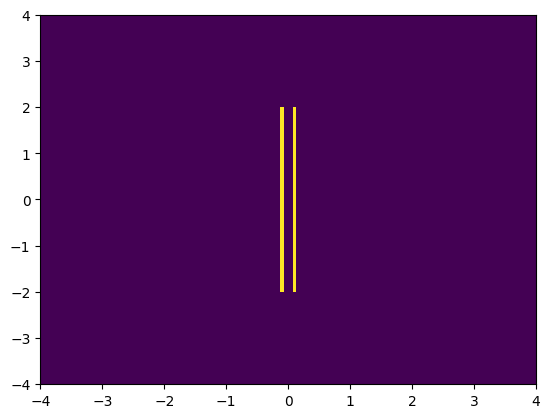

In [23]:
d = 0.2 * unit.mm
D = 0.05 * unit.mm
x = np.linspace(-4, 4, 1600) * unit.mm
xv, yv = np.meshgrid(x, x)

U0 = ((np.abs(xv - d/2) < D/2 ) + (np.abs(xv + d/2) < D/2)) * (np.abs(yv) < 2 * unit.mm)
U0 = U0.astype(float)
plt.pcolormesh(xv, yv, U0)

In [24]:
def compute_U(U0, xv, yv, wavelength, z):
    from scipy.fft import fft2, fftfreq, fftshift, ifft2
    A = fft2(U0)
    k = 2 * np.pi / wavelength
    kx = fftfreq(len(xv), np.diff(xv[0])[0]) * 2 * np.pi
    ky = fftfreq(len(yv), np.diff(yv[:,0])[0]) * 2 * np.pi
    kxv, kyv = np.meshgrid(kx, ky)
    return ifft2(A * np.exp(1j * k * z * np.sqrt(1 - (kxv / k)**2 - (kyv / k)**2)))

/opt/homebrew/lib/python3.13/site-packages/scipy/fft/_basic_backend.py:56: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.asarray(x)
/opt/homebrew/lib/python3.13/site-packages/matplotlib/cbook.py:684: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


Text(0, 0.5, 'y [mm]')

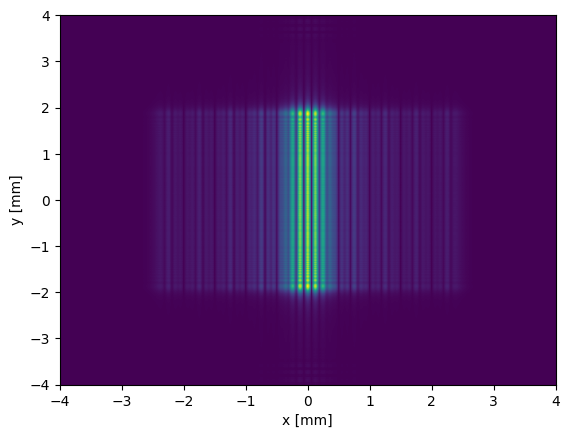

In [34]:
z = 5 * unit.cm
U = compute_U(U0, xv, yv, wavelength,  z)
plt.pcolormesh(xv, yv, np.abs(U))
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')

Again, we can confirm this result with diffraction theory.

For double slit diffraction, the minima of intensity occur at angles $\theta$ where:
$$D \sin \theta = (m + \frac{1}{2}) \lambda, \quad m = 0, \pm 1, \pm 2, \ldots$$

Plug in expression of $\sin \theta$ gives us the positions of minima on the observation plane:
$$x = \pm (m + \frac{1}{2}) \frac{\lambda z}{d} = \pm (m + \frac{1}{2}) \frac{\lambda d}{\sqrt{d^2 - (m + \frac{1}{2})^2 \lambda^2}}$$

(-1.0, 1.0)

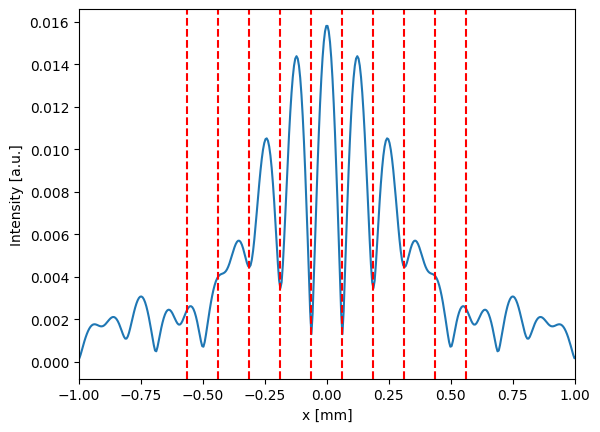

In [41]:
m = np.arange(0, 5, 1)
x_min_interference = (
    z * (m + 0.5) * wavelength
    / np.sqrt(d**2 - (m + 0.5)**2 * wavelength**2)
).to(unit.mm)

plt.plot(x, np.abs(U[200]))
for xm in x_min_interference:
    plt.axvline(xm.magnitude, color='r', linestyle='--')
    plt.axvline(-xm.magnitude, color='r', linestyle='--')
plt.xlabel('x [mm]')
plt.ylabel('Intensity [a.u.]')
plt.xlim(-1, 1)

## Reference
- (Luke Polson's Tutorial)[https://www.youtube.com/watch?v=QeNHF-H_ANM]
- Goodman, J.W. (1996). Introduction to Fourier Optics; Second Edition.